# HW3: MLP 신경망 성능 분석 실험

모든 실험은 동일 조건을 최대한 유지하고, 손실/정확도 곡선 및 정량 비교 표를 제공합니다.
- 실험 A: CrossEntropy vs MSE(+softmax)
- 실험 B: ReLU vs LeakyReLU vs Sigmoid
- 실험 C: SGD vs SGD+Momentum vs Adam

In [17]:
"""공통 설정 및 유틸리티 로딩 셀."""

import os
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from utils import (
    set_seed,
    get_fashion_mnist,
    get_digits,
    get_make_moons,
    get_make_circles,
    plot_loss_acc,
    plot_activation_distributions,
    plot_dead_relu_heatmap,
    plot_gradient_flow_heatmap,
    collect_layer_activations,
    compute_dead_relu_ratio,
    collect_gradient_norms,
)

# 결과 저장 경로
OUTPUT_BASE = "outputs"
os.makedirs(OUTPUT_BASE, exist_ok=True)

# 실행 환경 확인
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

device: cpu


## 1. 공통 설정 및 유틸리티 로딩

필요 라이브러리를 임포트하고 utils.py의 공통 함수를 로딩합니다. 

## 2. 데이터 로더 및 시드 고정

모든 실험에서 재현성을 위해 seed를 고정하고, 필요한 데이터셋을 미리 로딩합니다.

In [18]:
"""시드 고정과 데이터 로더 구성."""

# 재현성 보장
set_seed(42)

# 실험 A/C: Fashion-MNIST, Digits
fashion_train, fashion_test, fashion_classes = get_fashion_mnist(batch_size=64)
digits_train, digits_test, digits_classes = get_digits(batch_size=64)

# 실험 B: make_moons, make_circles
moons_train, moons_test, moons_classes = get_make_moons(batch_size=64)
circles_train, circles_test, circles_classes = get_make_circles(batch_size=64)

print("Fashion-MNIST classes:", fashion_classes)
print("Digits classes:", digits_classes)
print("Moons classes:", moons_classes)
print("Circles classes:", circles_classes)

Fashion-MNIST classes: 10
Digits classes: 10
Moons classes: 2
Circles classes: 2


## 3. 모델 정의 유틸리티 (MLP 생성)

실험 조건을 동일하게 유지하기 위해 공통 MLP 생성 함수를 사용합니다. 활성화 함수는 인자로 전달합니다.

In [19]:
"""MLP 생성 및 초기화 함수."""


def get_activation(name: str) -> nn.Module:
    """활성화 함수 모듈을 반환한다."""
    name = name.lower()
    if name == "relu":
        return nn.ReLU()
    if name == "leakyrelu":
        return nn.LeakyReLU(0.1)
    if name == "sigmoid":
        return nn.Sigmoid()
    raise ValueError(f"Unsupported activation: {name}")


def build_mlp(
    input_size: int,
    num_classes: int,
    activation: str = "relu",
    with_flatten: bool = False,
) -> nn.Module:
    """공통 MLP 모델을 생성한다.

    Args:
        activation: "relu", "leakyrelu", "sigmoid" 중 하나.
        with_flatten: 이미지 입력일 때 Flatten 적용 여부.
    """
    act = get_activation(activation)
    layers = []
    if with_flatten:
        # Fashion-MNIST는 (1, 28, 28) 입력 → 1차원으로 변환
        layers.append(nn.Flatten())
    layers.extend([
        nn.Linear(input_size, 256),
        act,
        nn.Linear(256, 128),
        get_activation(activation),
        nn.Linear(128, num_classes),
    ])
    return nn.Sequential(*layers)


def init_weights_small(model: nn.Module, std: float = 0.01) -> None:
    """Dead ReLU 유도를 위해 작은 표준편차로 가중치를 초기화한다."""
    for module in model.modules():
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=std)
            nn.init.zeros_(module.bias)

In [20]:
# """다양한 MLP 구조 실험용 — 구조 확인 후 주석처리 예정."""


# def build_mlp_custom(
#     input_size: int,
#     num_classes: int,
#     hidden_sizes: list[int],
#     activation: str = "relu",
#     with_flatten: bool = False,
# ) -> nn.Module:
#     """hidden_sizes 리스트로 깊이/너비를 자유롭게 설정하는 MLP 생성 함수.

#     Args:
#         hidden_sizes: 은닉층 크기 목록. 예) [128] → 1층, [512, 256, 128, 64] → 4층.
#     """
#     layers = []
#     if with_flatten:
#         layers.append(nn.Flatten())
#     in_size = input_size
#     for out_size in hidden_sizes:
#         layers.append(nn.Linear(in_size, out_size))
#         layers.append(get_activation(activation))
#         in_size = out_size
#     layers.append(nn.Linear(in_size, num_classes))
#     return nn.Sequential(*layers)


# # ── 구조 확인 (Fashion-MNIST 기준: input=784, num_classes=10) ──
# INPUT_SIZE = 28 * 28
# NUM_CLASSES = 10

# shallow_model = build_mlp_custom(INPUT_SIZE, NUM_CLASSES, hidden_sizes=[128])
# default_model = build_mlp_custom(INPUT_SIZE, NUM_CLASSES, hidden_sizes=[256, 128])
# deeper_model  = build_mlp_custom(INPUT_SIZE, NUM_CLASSES, hidden_sizes=[512, 256, 128, 64])

# for name, model in [("Shallow [128]", shallow_model),
#                     ("Default [256→128]", default_model),
#                     ("Deeper [512→256→128→64]", deeper_model)]:
#     total_params = sum(p.numel() for p in model.parameters())
#     print(f"=== {name}  (params: {total_params:,}) ===")
#     print(model)
#     print()

## 4. 학습/평가 루프 구현

직접 작성한 `for epoch in range(...)` 형태의 학습 루프와 평가 루프를 정의합니다.

In [21]:
"""학습/평가 루프."""


def train_one_epoch(
    model: nn.Module,
    loader,
    loss_fn,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    use_softmax_output: bool = False,
) -> tuple[float, float]:
    """단일 에폭 학습을 수행한다."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)

        if use_softmax_output:
            # MSE 실험: softmax로 확률 분포 변환 후 one-hot과 비교
            probs = torch.softmax(outputs, dim=1)
            targets_onehot = torch.zeros_like(probs)
            targets_onehot.scatter_(1, targets.unsqueeze(1), 1.0)
            loss = loss_fn(probs, targets_onehot)
            preds = probs.argmax(dim=1)
        else:
            # CrossEntropy 실험: logits 그대로 사용
            loss = loss_fn(outputs, targets)
            preds = outputs.argmax(dim=1)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        correct += (preds == targets).sum().item()
        total += inputs.size(0)

    return total_loss / total, correct / total


def evaluate_model(
    model: nn.Module,
    loader,
    loss_fn,
    device: torch.device,
    use_softmax_output: bool = False,
) -> tuple[float, float]:
    """평가 세트에 대한 loss와 accuracy를 계산한다."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)

            if use_softmax_output:
                probs = torch.softmax(outputs, dim=1)
                targets_onehot = torch.zeros_like(probs)
                targets_onehot.scatter_(1, targets.unsqueeze(1), 1.0)
                loss = loss_fn(probs, targets_onehot)
                preds = probs.argmax(dim=1)
            else:
                loss = loss_fn(outputs, targets)
                preds = outputs.argmax(dim=1)

            total_loss += loss.item() * inputs.size(0)
            correct += (preds == targets).sum().item()
            total += inputs.size(0)

    return total_loss / total, correct / total


def train_model(
    model: nn.Module,
    train_loader,
    test_loader,
    loss_fn,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    epochs: int,
    use_softmax_output: bool = False,
    scheduler=None,
    grad_history: dict | None = None,
    snapshot_epochs: list[int] | None = None,
    activation_snapshots: dict | None = None,
) -> tuple[list, list, list, list]:
    """전체 학습 루프를 수행하고 loss/accuracy 기록을 반환한다.

    Args:
        snapshot_epochs: activation 분포를 캡처할 epoch 번호 목록 (1-indexed).
        activation_snapshots: {epoch: {layer: activations}} 형태로 결과가 저장될 dict.
    """
    train_losses, train_accs, test_losses, test_accs = [], [], [], []

    for epoch in range(epochs):
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, loss_fn, optimizer, device, use_softmax_output
        )
        te_loss, te_acc = evaluate_model(
            model, test_loader, loss_fn, device, use_softmax_output
        )

        train_losses.append(tr_loss)
        train_accs.append(tr_acc)
        test_losses.append(te_loss)
        test_accs.append(te_acc)

        # Gradient 흐름 기록 (히트맵 시각화용)
        if grad_history is not None:
            collect_gradient_norms(grad_history, model)

        # Save activation snapshot at specified epoch (for early / mid / late analysis)
        if snapshot_epochs and activation_snapshots is not None and (epoch + 1) in snapshot_epochs:
            activation_snapshots[epoch + 1] = collect_layer_activations(
                model, train_loader, device, max_batches=5
            )

        if scheduler is not None:
            scheduler.step()

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(
                f"Epoch {epoch+1:>3}/{epochs} | "
                f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | "
                f"Test Loss {te_loss:.4f} Acc {te_acc:.4f}"
            )

    return train_losses, train_accs, test_losses, test_accs


def convergence_epoch(test_losses: list[float]) -> int:
    """테스트 손실이 최소가 되는 에폭을 수렴 epoch으로 정의한다."""
    min_idx = min(range(len(test_losses)), key=lambda i: test_losses[i])
    return min_idx + 1

## 5. 실험 A: CrossEntropy vs MSE

동일한 모델/옵티마이저 조건에서 손실 함수만 변경하여 성능 차이를 비교합니다.

Epoch   1/30 | Train Loss 0.4938 Acc 0.8183 | Test Loss 0.4220 Acc 0.8457
Epoch  10/30 | Train Loss 0.2231 Acc 0.9157 | Test Loss 0.3641 Acc 0.8778
Epoch  20/30 | Train Loss 0.1452 Acc 0.9445 | Test Loss 0.3982 Acc 0.8859
Epoch  30/30 | Train Loss 0.1038 Acc 0.9611 | Test Loss 0.4867 Acc 0.8834


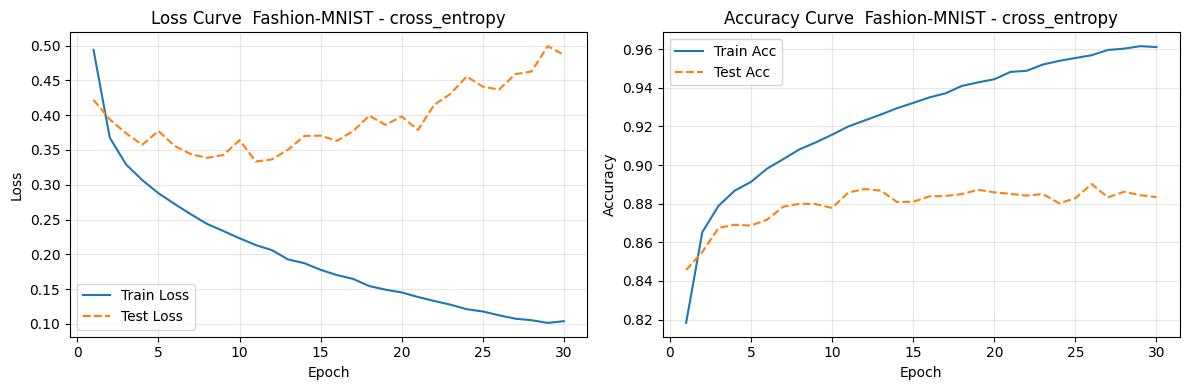

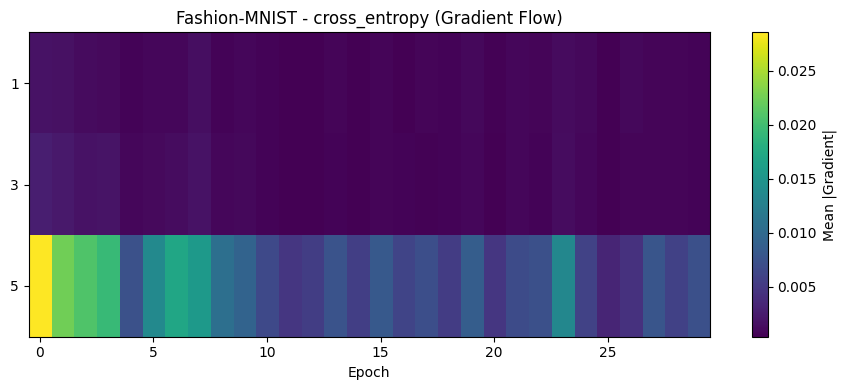

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:1

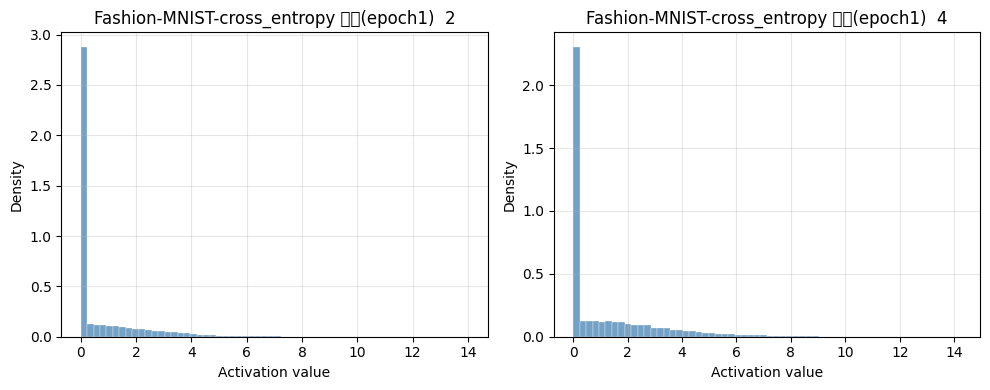

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


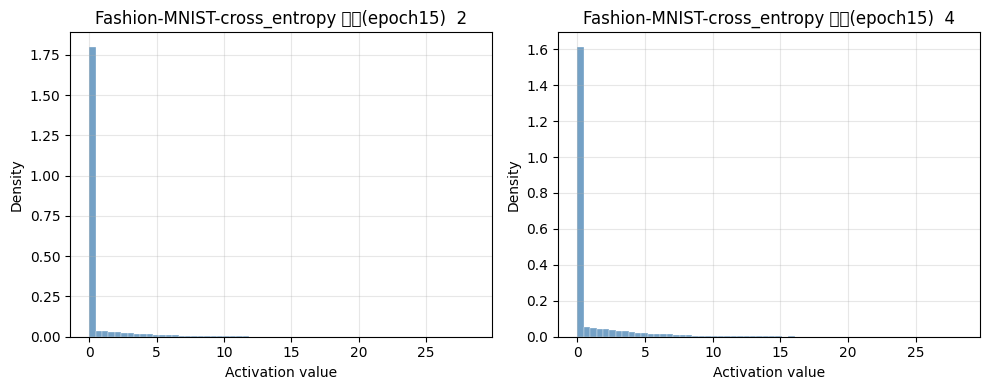

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


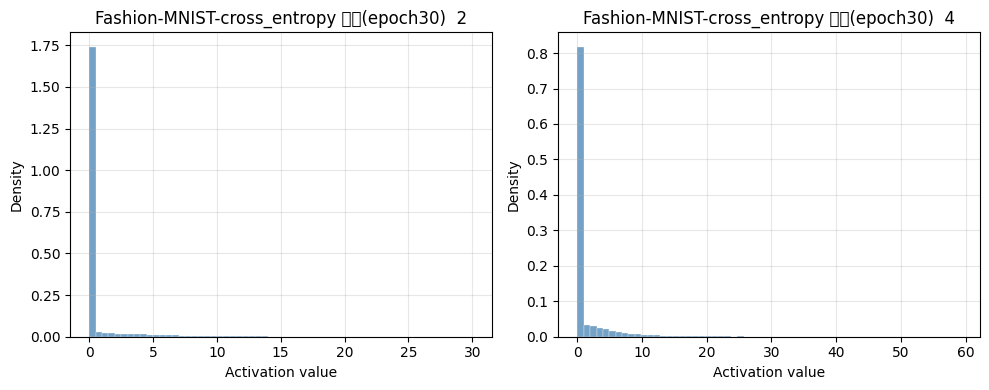

Epoch   1/30 | Train Loss 0.0259 Acc 0.8164 | Test Loss 0.0220 Acc 0.8468
Epoch  10/30 | Train Loss 0.0131 Acc 0.9125 | Test Loss 0.0191 Acc 0.8713
Epoch  20/30 | Train Loss 0.0097 Acc 0.9366 | Test Loss 0.0180 Acc 0.8823
Epoch  30/30 | Train Loss 0.0077 Acc 0.9514 | Test Loss 0.0176 Acc 0.8884


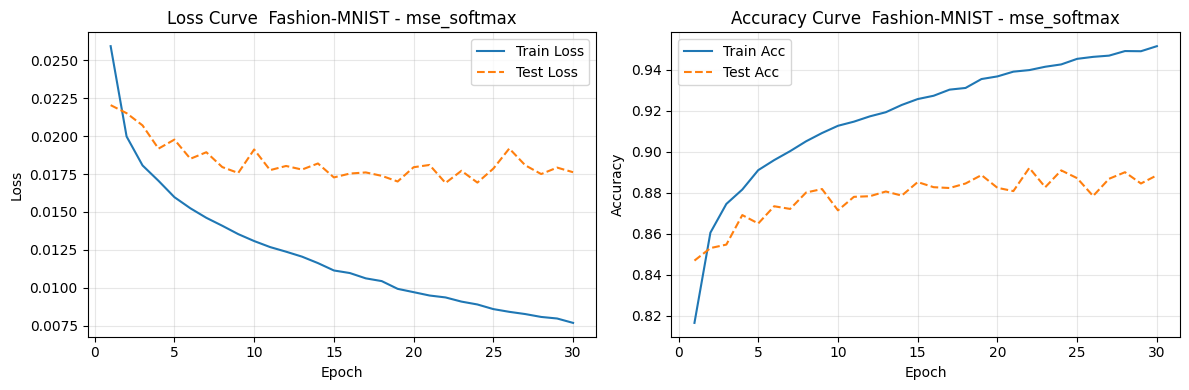

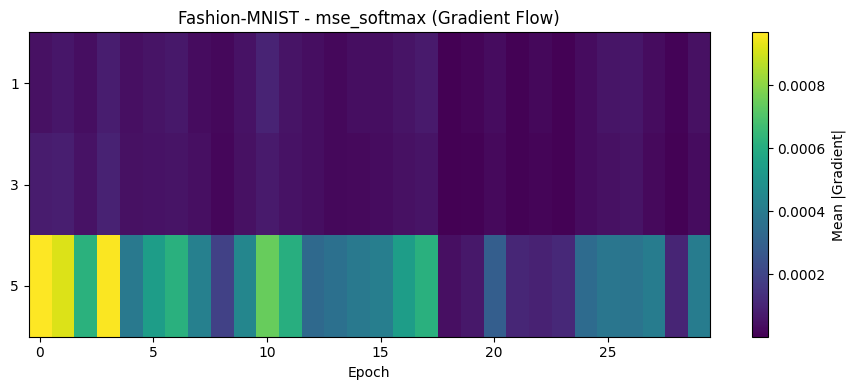

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:1

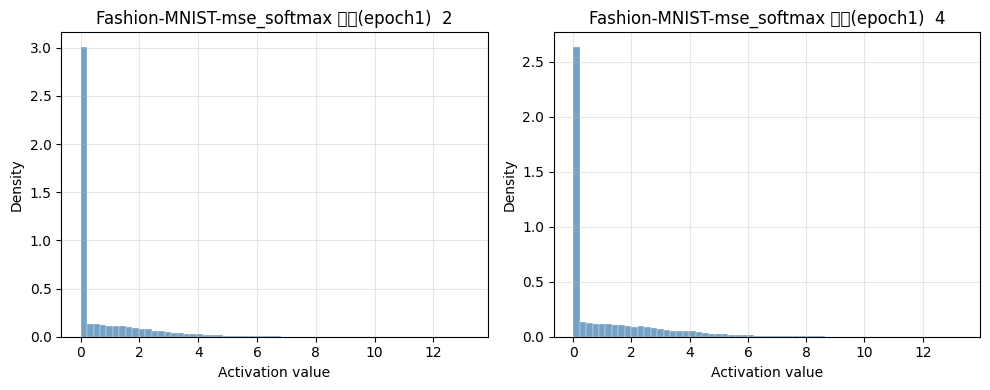

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


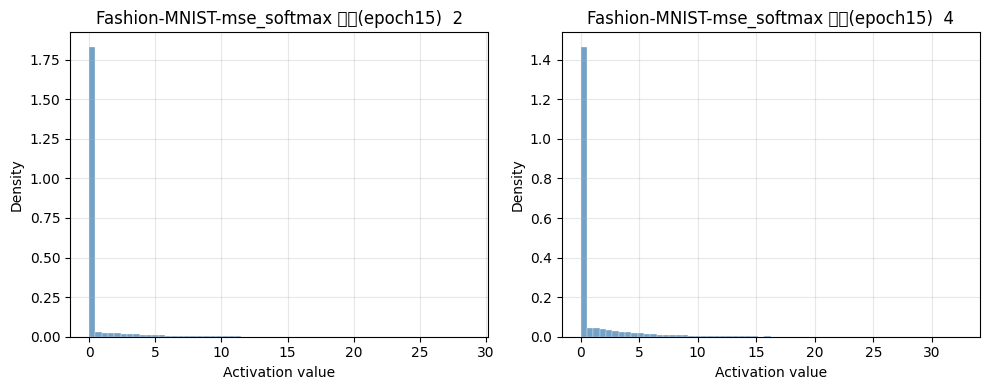

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


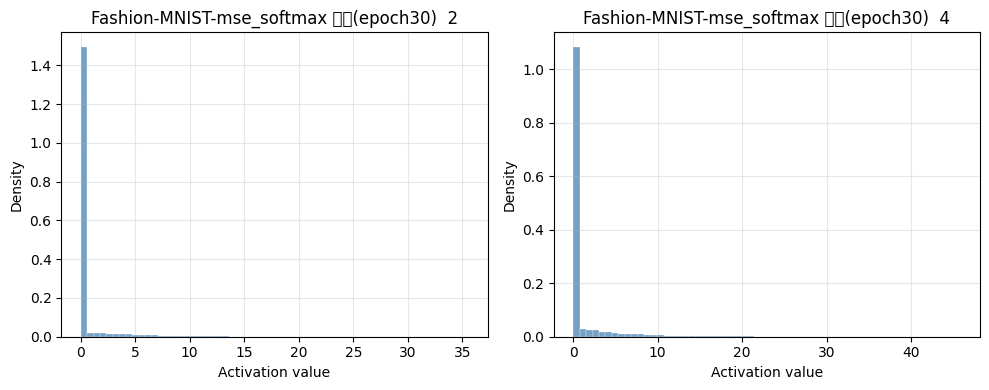

Epoch   1/30 | Train Loss 1.8094 Acc 0.6507 | Test Loss 1.0963 Acc 0.8194
Epoch  10/30 | Train Loss 0.0186 Acc 0.9986 | Test Loss 0.0962 Acc 0.9722
Epoch  20/30 | Train Loss 0.0034 Acc 1.0000 | Test Loss 0.0897 Acc 0.9778
Epoch  30/30 | Train Loss 0.0013 Acc 1.0000 | Test Loss 0.0887 Acc 0.9778


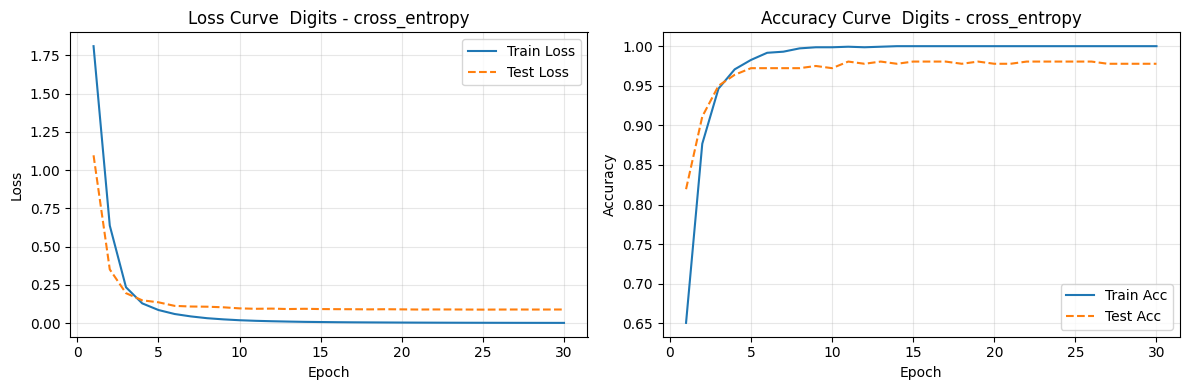

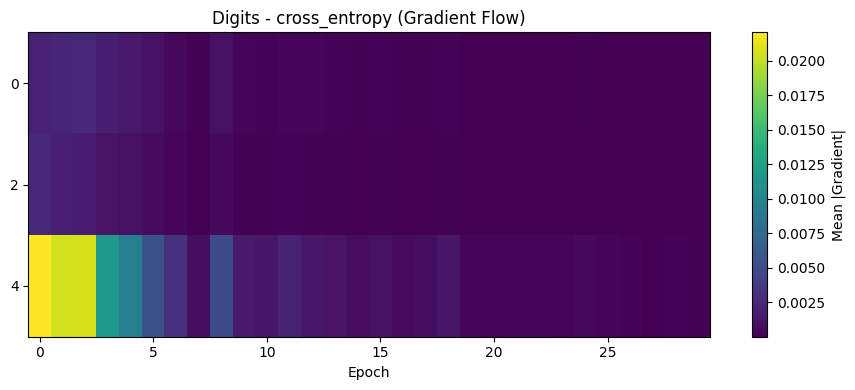

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:1

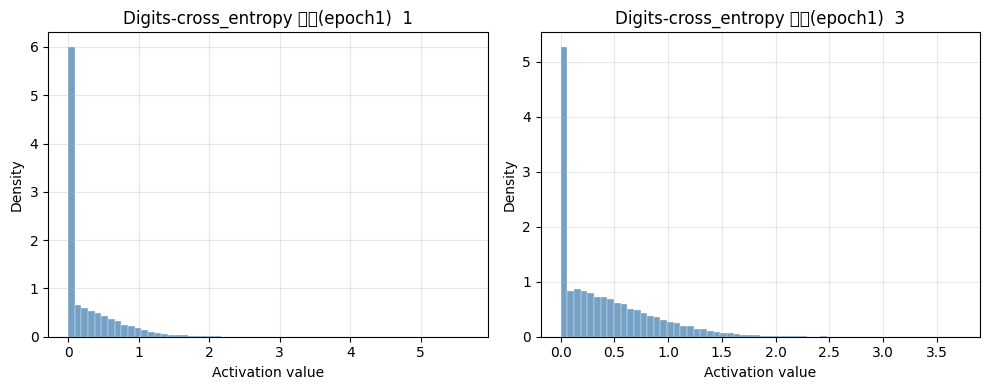

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


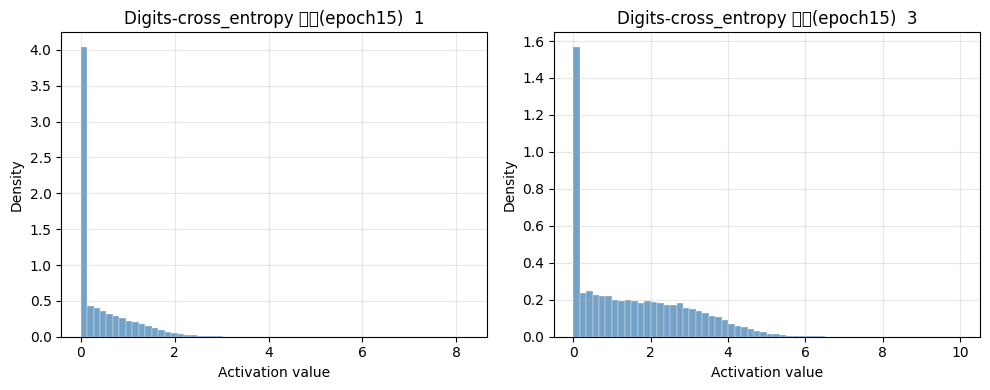

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


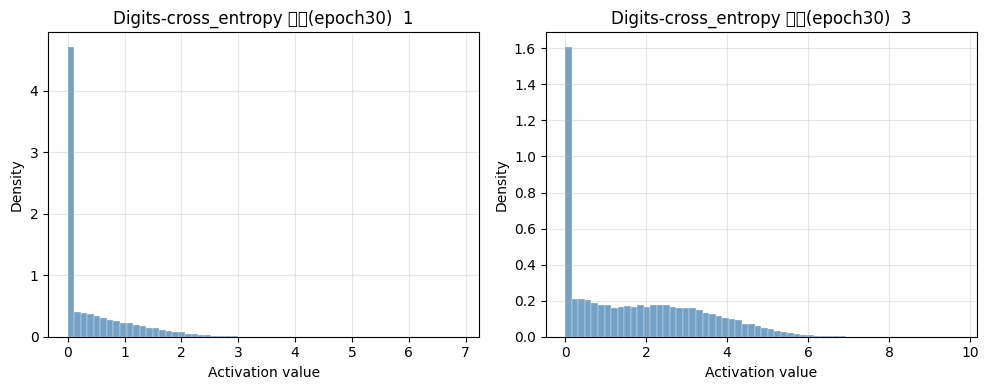

Epoch   1/30 | Train Loss 0.0731 Acc 0.6006 | Test Loss 0.0450 Acc 0.7694
Epoch  10/30 | Train Loss 0.0007 Acc 0.9979 | Test Loss 0.0037 Acc 0.9750
Epoch  20/30 | Train Loss 0.0002 Acc 0.9993 | Test Loss 0.0037 Acc 0.9778
Epoch  30/30 | Train Loss 0.0000 Acc 1.0000 | Test Loss 0.0032 Acc 0.9750


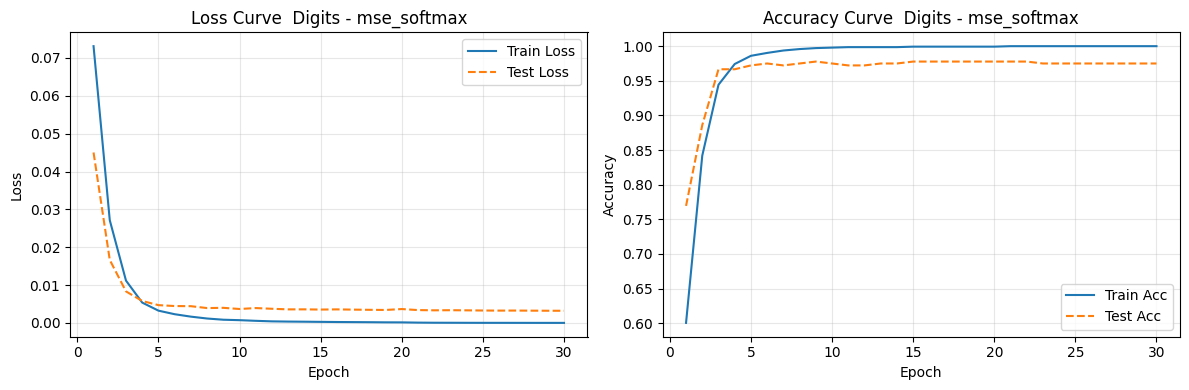

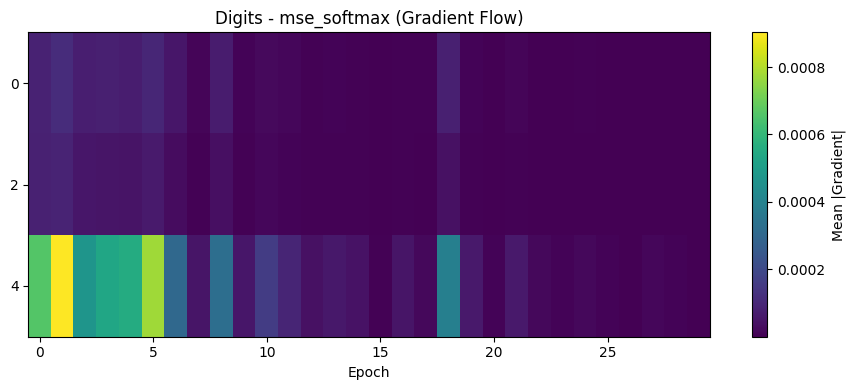

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:1

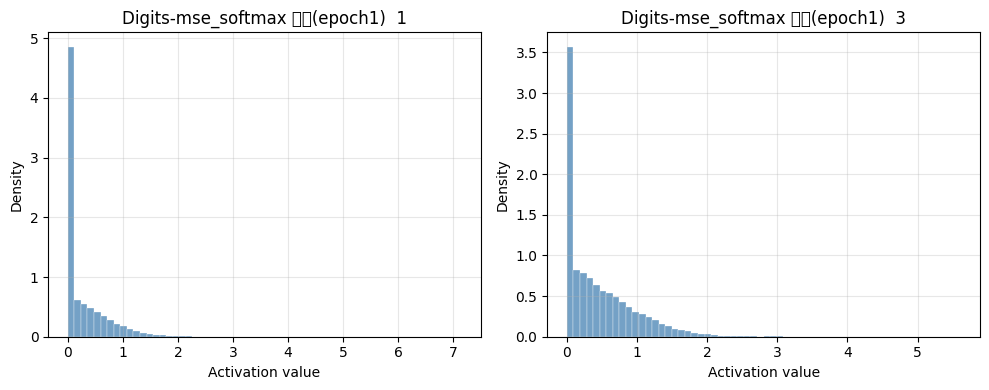

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


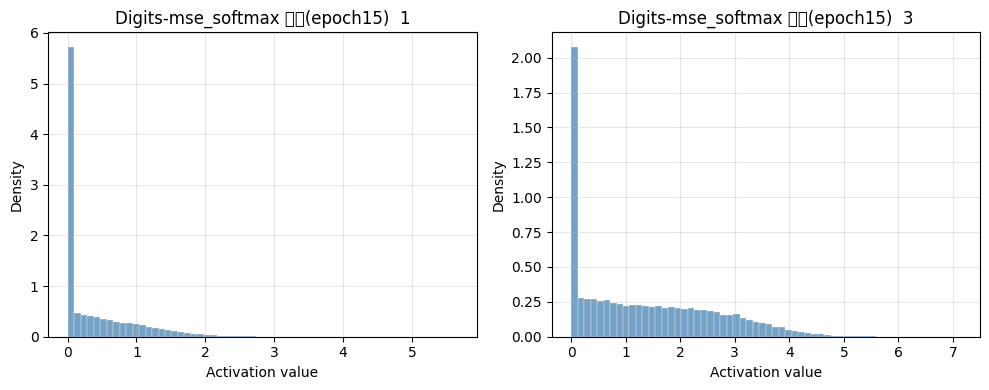

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


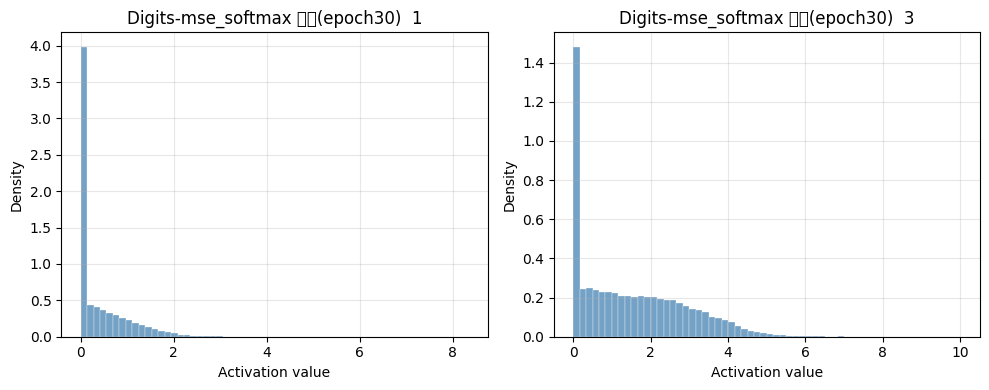

,dataset,loss,final_acc,min_loss,conv_epoch
0,Fashion-MNIST,cross_entropy,88.340000,0.333500,11
1,Fashion-MNIST,mse_softmax,88.840000,0.016912,22
2,Digits,cross_entropy,97.777778,0.087940,25
3,Digits,mse_softmax,97.500000,0.003225,30


In [28]:
"""실험 A 실행."""

EXP_A_EPOCHS = 30
EXP_A_LR = 0.001
EXP_A_SNAPSHOTS = [1, 15, 30]  # early / mid / late

exp_a_results = []


def run_exp_a(
    dataset_name: str,
    train_loader,
    test_loader,
    input_size: int,
    num_classes: int,
    with_flatten: bool,
):
    for loss_name in ["cross_entropy", "mse"]:
        model = build_mlp(
            input_size=input_size,
            num_classes=num_classes,
            activation="relu",
            with_flatten=with_flatten,
        ).to(DEVICE)

        if loss_name == "cross_entropy":
            loss_fn = nn.CrossEntropyLoss()
            use_softmax_output = False
            loss_tag = "cross_entropy"
        else:
            loss_fn = nn.MSELoss()
            use_softmax_output = True
            loss_tag = "mse_softmax"

        optimizer = torch.optim.Adam(model.parameters(), lr=EXP_A_LR)
        grad_history: dict = {}
        activation_snapshots: dict = {}

        train_losses, train_accs, test_losses, test_accs = train_model(
            model=model,
            train_loader=train_loader,
            test_loader=test_loader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=DEVICE,
            epochs=EXP_A_EPOCHS,
            use_softmax_output=use_softmax_output,
            grad_history=grad_history,
            snapshot_epochs=EXP_A_SNAPSHOTS,
            activation_snapshots=activation_snapshots,
        )

        out_dir = os.path.join(OUTPUT_BASE, "experiment_a", dataset_name, loss_tag)
        os.makedirs(out_dir, exist_ok=True)

        # Loss/Accuracy 곡선
        plot_loss_acc(
            train_losses,
            train_accs,
            test_losses,
            test_accs,
            title=f"{dataset_name} - {loss_tag}",
            save_path=os.path.join(out_dir, "loss_acc.png"),
        )

        # Gradient 흐름 히트맵
        plot_gradient_flow_heatmap(
            grad_history,
            title=f"{dataset_name} - {loss_tag} (Gradient Flow)",
            save_path=os.path.join(out_dir, "grad_flow_heatmap.png"),
        )

        # Activation distribution visualization (early / mid / late)
        epoch_labels = {1: "early", 15: "mid", 30: "late"}
        for ep, acts in activation_snapshots.items():
            label = epoch_labels.get(ep, f"ep{ep}")
            plot_activation_distributions(
                acts,
                plot_type="histogram",
                title_prefix=f"{dataset_name}-{loss_tag} {label}(epoch{ep})",
                save_path=os.path.join(out_dir, f"activation_hist_{label}.png"),
            )

        exp_a_results.append({
            "dataset": dataset_name,
            "loss": loss_tag,
            "final_acc": test_accs[-1] * 100.0,
            "min_loss": min(test_losses),
            "conv_epoch": convergence_epoch(test_losses),
        })


# Fashion-MNIST
run_exp_a(
    dataset_name="Fashion-MNIST",
    train_loader=fashion_train,
    test_loader=fashion_test,
    input_size=28 * 28,
    num_classes=fashion_classes,
    with_flatten=True,
)

# Digits
run_exp_a(
    dataset_name="Digits",
    train_loader=digits_train,
    test_loader=digits_test,
    input_size=64,
    num_classes=digits_classes,
    with_flatten=False,
)

exp_a_df = pd.DataFrame(exp_a_results)
exp_a_df

## 6. 실험 B: ReLU vs LeakyReLU vs Sigmoid

make_moons 데이터에서 활성화 함수에 따른 학습 차이를 비교합니다. Dead ReLU 유도를 위해 작은 표준편차로 가중치를 초기화합니다.

Epoch   1/200 | Train Loss 0.4183 Acc 0.8237 | Test Loss 0.2730 Acc 0.8850
Epoch  10/200 | Train Loss 0.0823 Acc 0.9675 | Test Loss 0.1217 Acc 0.9575
Epoch  20/200 | Train Loss 0.0772 Acc 0.9731 | Test Loss 0.1045 Acc 0.9500
Epoch  30/200 | Train Loss 0.0801 Acc 0.9712 | Test Loss 0.0986 Acc 0.9525
Epoch  40/200 | Train Loss 0.0762 Acc 0.9694 | Test Loss 0.1125 Acc 0.9525
Epoch  50/200 | Train Loss 0.0811 Acc 0.9706 | Test Loss 0.1422 Acc 0.9500
Epoch  60/200 | Train Loss 0.0700 Acc 0.9706 | Test Loss 0.1158 Acc 0.9525
Epoch  70/200 | Train Loss 0.0707 Acc 0.9731 | Test Loss 0.1029 Acc 0.9550
Epoch  80/200 | Train Loss 0.0667 Acc 0.9719 | Test Loss 0.1006 Acc 0.9600
Epoch  90/200 | Train Loss 0.0632 Acc 0.9775 | Test Loss 0.1052 Acc 0.9550
Epoch 100/200 | Train Loss 0.0718 Acc 0.9744 | Test Loss 0.1032 Acc 0.9575
Epoch 110/200 | Train Loss 0.0656 Acc 0.9744 | Test Loss 0.1042 Acc 0.9550
Epoch 120/200 | Train Loss 0.0685 Acc 0.9725 | Test Loss 0.0966 Acc 0.9575
Epoch 130/200 | Train Los

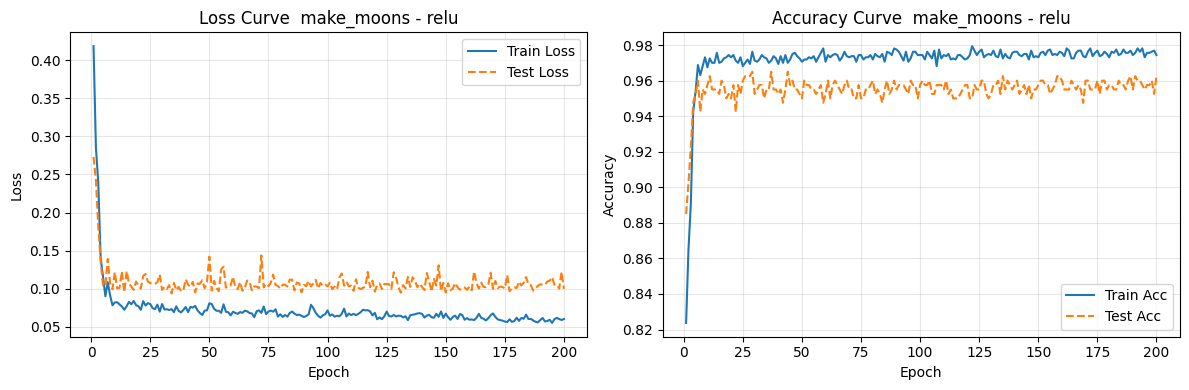

Epoch   1/200 | Train Loss 0.4150 Acc 0.8075 | Test Loss 0.3013 Acc 0.8725
Epoch  10/200 | Train Loss 0.0767 Acc 0.9706 | Test Loss 0.1327 Acc 0.9525
Epoch  20/200 | Train Loss 0.0682 Acc 0.9756 | Test Loss 0.1181 Acc 0.9550
Epoch  30/200 | Train Loss 0.0710 Acc 0.9725 | Test Loss 0.0953 Acc 0.9525
Epoch  40/200 | Train Loss 0.0705 Acc 0.9725 | Test Loss 0.1190 Acc 0.9525
Epoch  50/200 | Train Loss 0.0734 Acc 0.9706 | Test Loss 0.0956 Acc 0.9575
Epoch  60/200 | Train Loss 0.0709 Acc 0.9725 | Test Loss 0.1086 Acc 0.9525
Epoch  70/200 | Train Loss 0.0670 Acc 0.9731 | Test Loss 0.0925 Acc 0.9600
Epoch  80/200 | Train Loss 0.0666 Acc 0.9738 | Test Loss 0.1033 Acc 0.9600
Epoch  90/200 | Train Loss 0.0664 Acc 0.9756 | Test Loss 0.0966 Acc 0.9600
Epoch 100/200 | Train Loss 0.0732 Acc 0.9731 | Test Loss 0.1143 Acc 0.9650
Epoch 110/200 | Train Loss 0.0665 Acc 0.9750 | Test Loss 0.0965 Acc 0.9600
Epoch 120/200 | Train Loss 0.0634 Acc 0.9738 | Test Loss 0.0957 Acc 0.9625
Epoch 130/200 | Train Los

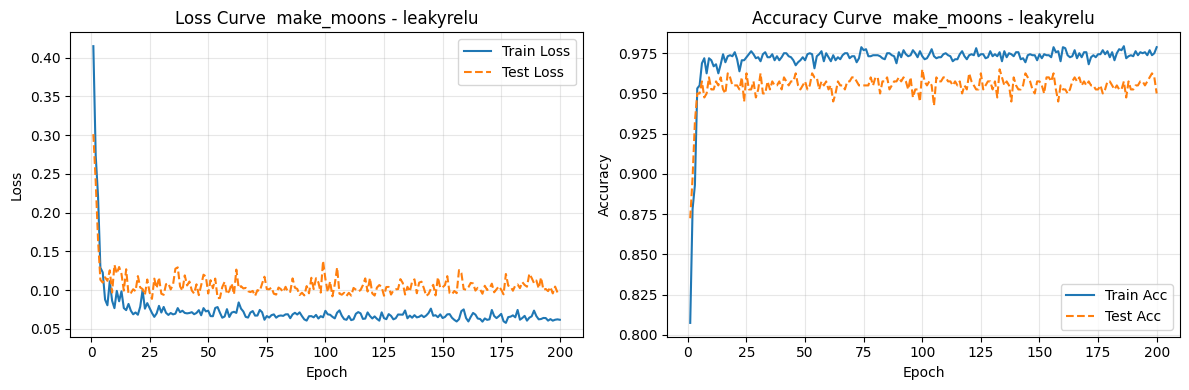

Epoch   1/200 | Train Loss 0.7035 Acc 0.5038 | Test Loss 0.6876 Acc 0.5000
Epoch  10/200 | Train Loss 0.2926 Acc 0.8781 | Test Loss 0.2762 Acc 0.8925
Epoch  20/200 | Train Loss 0.1206 Acc 0.9575 | Test Loss 0.1512 Acc 0.9400
Epoch  30/200 | Train Loss 0.0912 Acc 0.9669 | Test Loss 0.1052 Acc 0.9550
Epoch  40/200 | Train Loss 0.0827 Acc 0.9694 | Test Loss 0.0970 Acc 0.9525
Epoch  50/200 | Train Loss 0.0838 Acc 0.9712 | Test Loss 0.1206 Acc 0.9525
Epoch  60/200 | Train Loss 0.0868 Acc 0.9694 | Test Loss 0.0965 Acc 0.9525
Epoch  70/200 | Train Loss 0.0827 Acc 0.9706 | Test Loss 0.0994 Acc 0.9550
Epoch  80/200 | Train Loss 0.0730 Acc 0.9738 | Test Loss 0.0926 Acc 0.9500
Epoch  90/200 | Train Loss 0.0762 Acc 0.9700 | Test Loss 0.1008 Acc 0.9550
Epoch 100/200 | Train Loss 0.0749 Acc 0.9725 | Test Loss 0.0957 Acc 0.9550
Epoch 110/200 | Train Loss 0.0829 Acc 0.9688 | Test Loss 0.1012 Acc 0.9525
Epoch 120/200 | Train Loss 0.0758 Acc 0.9744 | Test Loss 0.0980 Acc 0.9575
Epoch 130/200 | Train Los

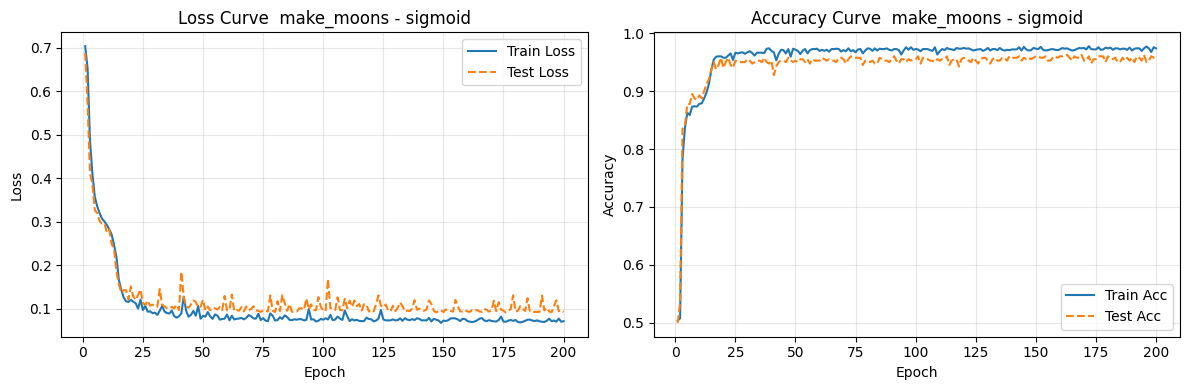

,activation,dead_relu_ratio(%),final_acc(%),min_loss,conv_epoch
0,relu,42.58,96.25,0.093952,34
1,leakyrelu,12.89,95.00,0.088645,26
2,sigmoid,0.00,96.00,0.091472,176


In [23]:
"""실험 B 실행."""

EXP_B_EPOCHS = 200
EXP_B_LR = 0.01
EXP_B_SNAPSHOTS = [1, 100, 200]  # early / mid / late

exp_b_results = []
exp_b_models = {}
exp_b_grads = {}
exp_b_act_snapshots = {}  # {activation: {epoch: {layer: activations}}}

for activation in ["relu", "leakyrelu", "sigmoid"]:
    model = build_mlp(
        input_size=2,
        num_classes=moons_classes,
        activation=activation,
        with_flatten=False,
    ).to(DEVICE)

    # Dead ReLU 유도용 작은 초기값
    init_weights_small(model, std=0.01)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=EXP_B_LR)
    grad_history: dict = {}
    activation_snapshots: dict = {}

    train_losses, train_accs, test_losses, test_accs = train_model(
        model=model,
        train_loader=moons_train,
        test_loader=moons_test,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=DEVICE,
        epochs=EXP_B_EPOCHS,
        use_softmax_output=False,
        grad_history=grad_history,
        snapshot_epochs=EXP_B_SNAPSHOTS,
        activation_snapshots=activation_snapshots,
    )

    out_dir = os.path.join(OUTPUT_BASE, "experiment_b", "make_moons", activation)
    os.makedirs(out_dir, exist_ok=True)

    plot_loss_acc(
        train_losses,
        train_accs,
        test_losses,
        test_accs,
        title=f"make_moons - {activation}",
        save_path=os.path.join(out_dir, "loss_acc.png"),
    )

    # Dead ReLU 비율 계산 — ReLU/LeakyReLU만 해당, Sigmoid는 0으로 처리
    dead_ratios = compute_dead_relu_ratio(
        model=model,
        loader=moons_train,
        device=DEVICE,
        max_batches=10,
    )
    # 레이어별 비율을 평균하여 모델 전체 대표값으로 사용
    dead_ratio_pct = float(np.mean(list(dead_ratios.values())) * 100) if dead_ratios else 0.0

    exp_b_results.append({
        "activation": activation,
        "dead_relu_ratio(%)": round(dead_ratio_pct, 2),
        "final_acc(%)": round(test_accs[-1] * 100.0, 2),
        "min_loss": round(min(test_losses), 6),
        "conv_epoch": convergence_epoch(test_losses),
    })

    exp_b_models[activation] = model
    exp_b_grads[activation] = grad_history
    exp_b_act_snapshots[activation] = activation_snapshots

exp_b_df = pd.DataFrame(exp_b_results)
exp_b_df

## 7. 실험 B: 활성화 분포/Dead ReLU/Gradient 흐름 시각화

활성화 분포 히스토그램, Dead ReLU 비율 히트맵, Gradient 흐름 히트맵을 생성합니다.

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:1

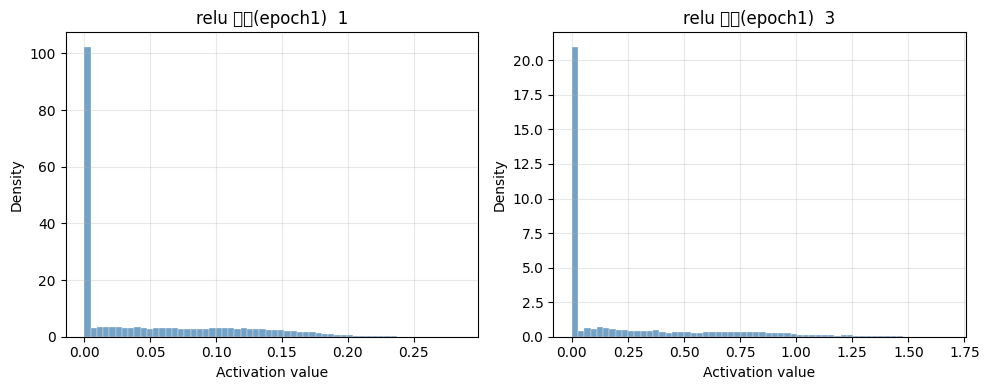

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


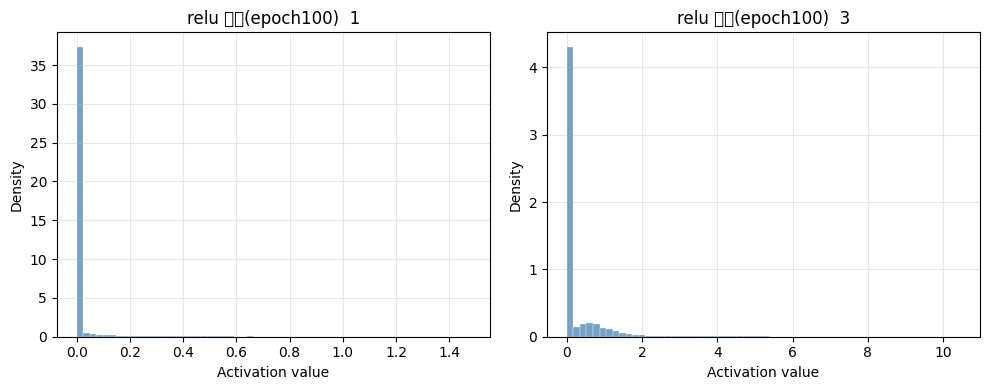

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


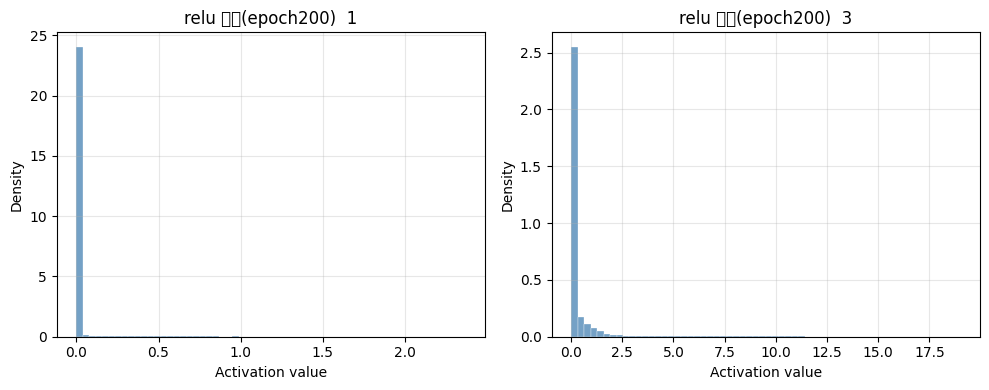

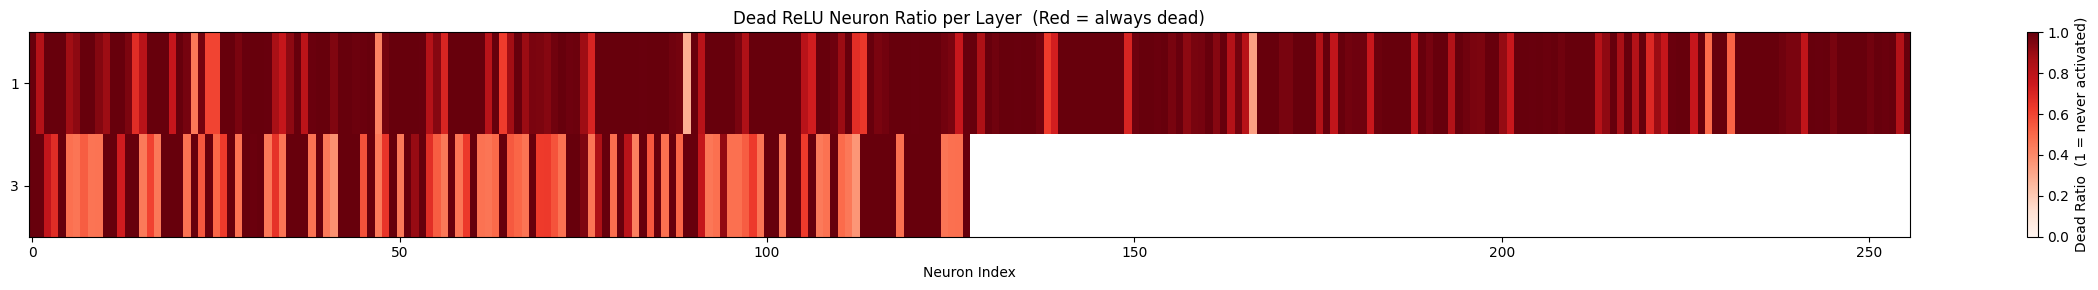

[relu] dead ratio: {'1': 0.40234375, '3': 0.4375}


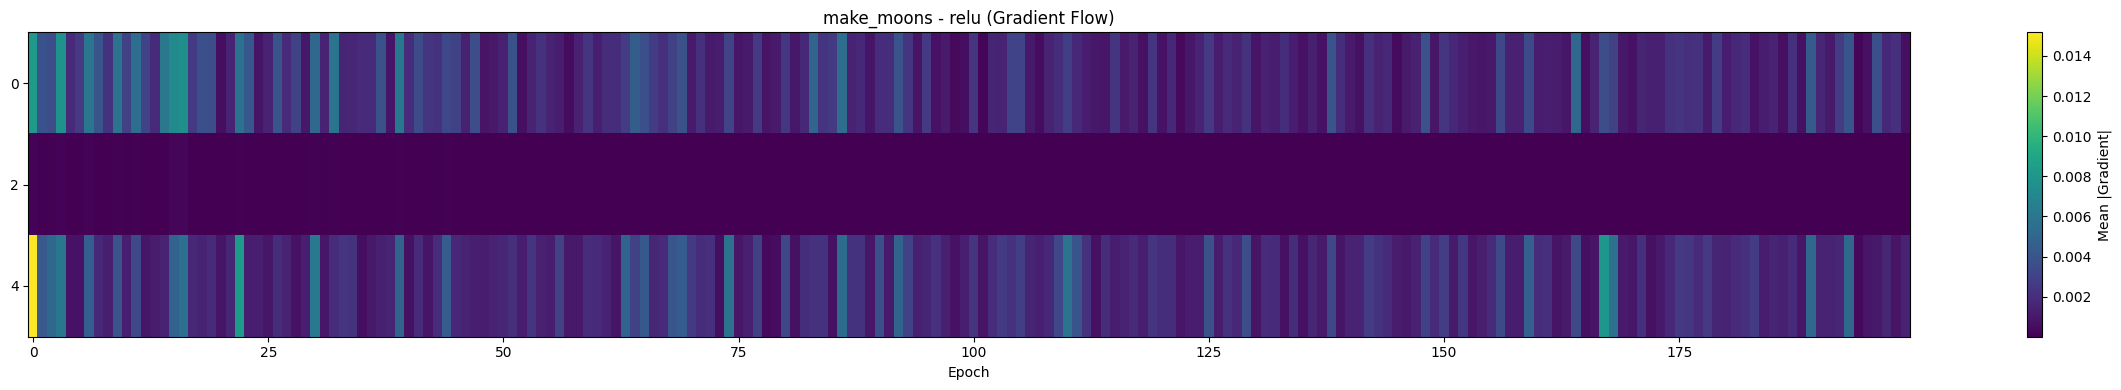

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:1

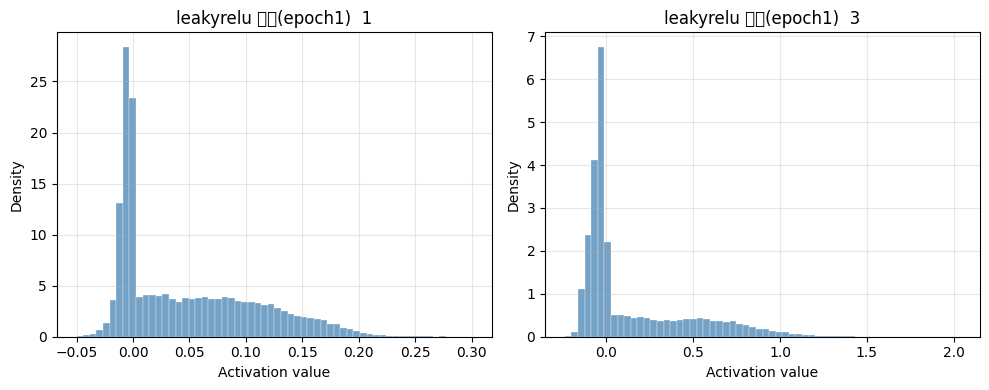

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


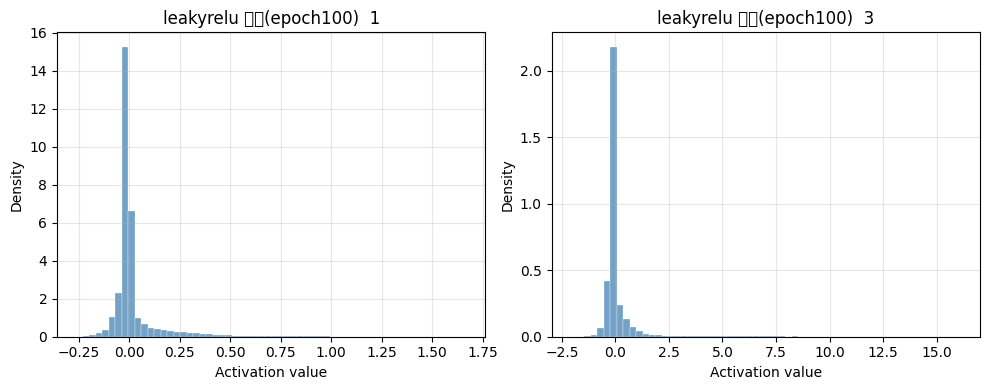

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


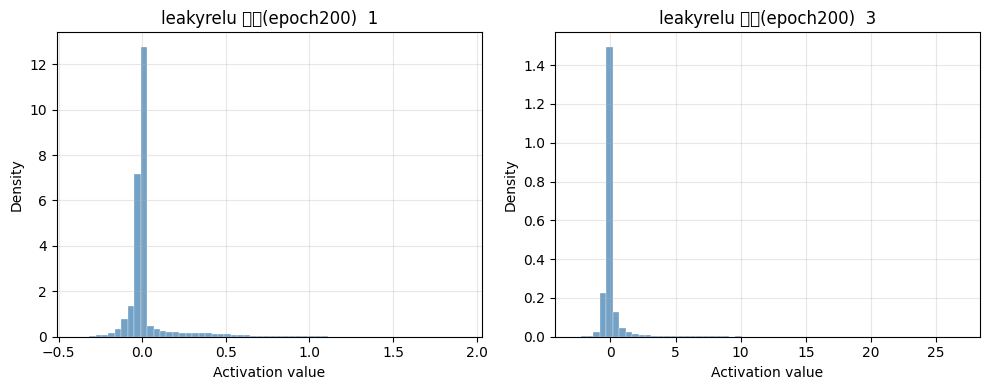

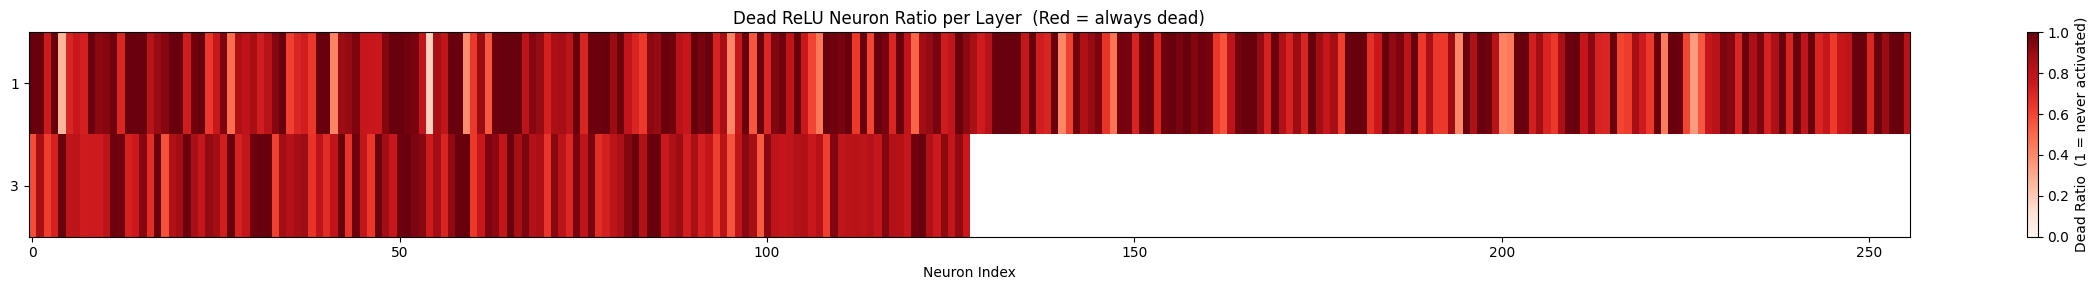

[leakyrelu] dead ratio: {'1': 0.1953125, '3': 0.0546875}


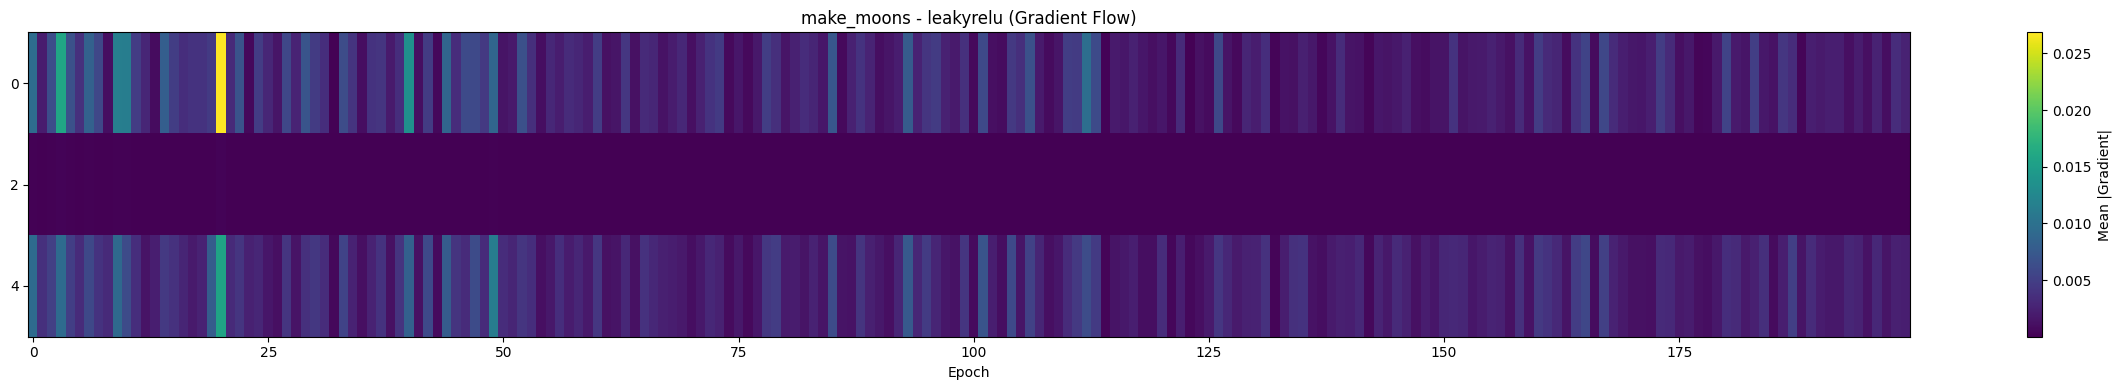

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:1

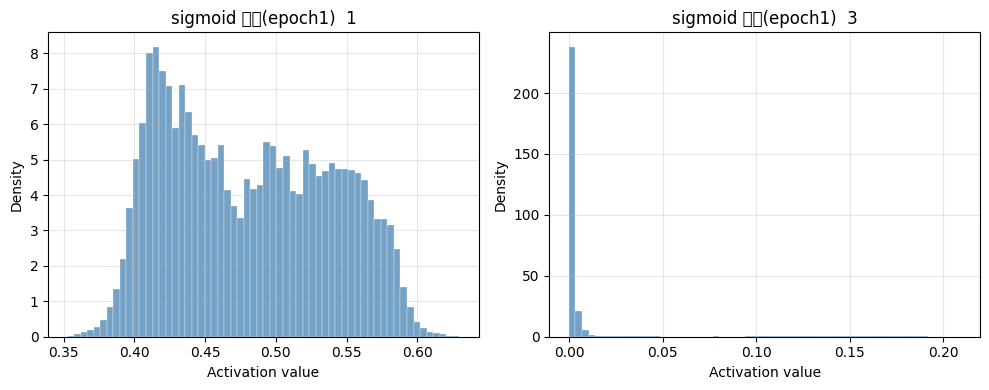

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


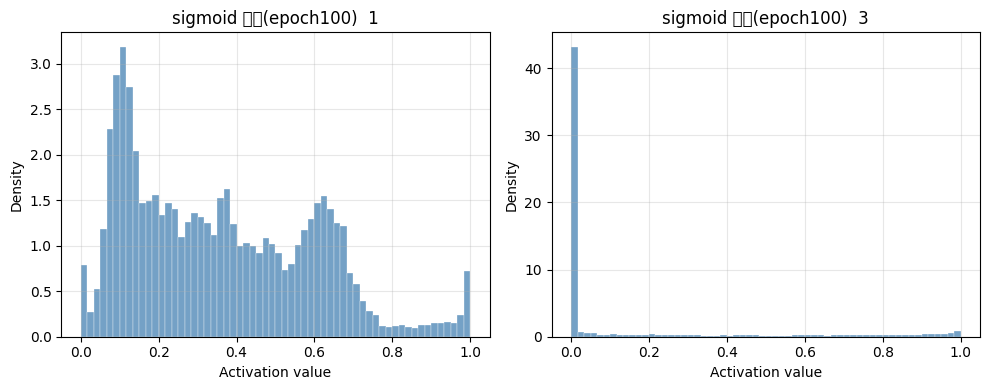

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


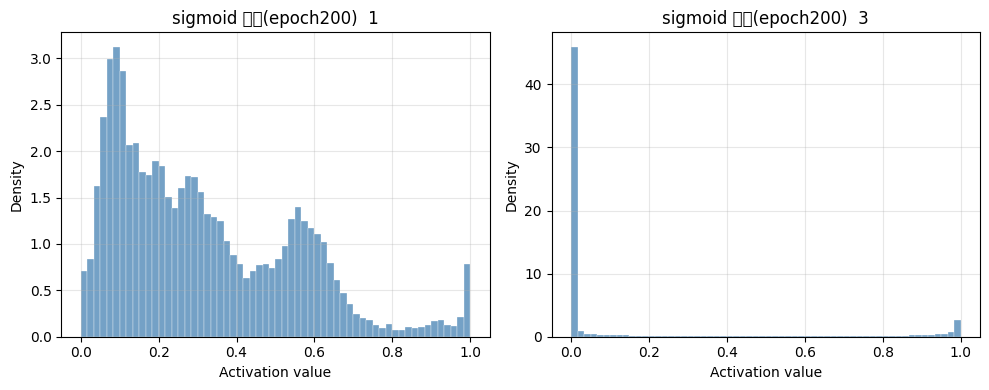

[경고] ReLU/LeakyReLU 레이어가 없습니다.
[sigmoid] dead ratio: {}


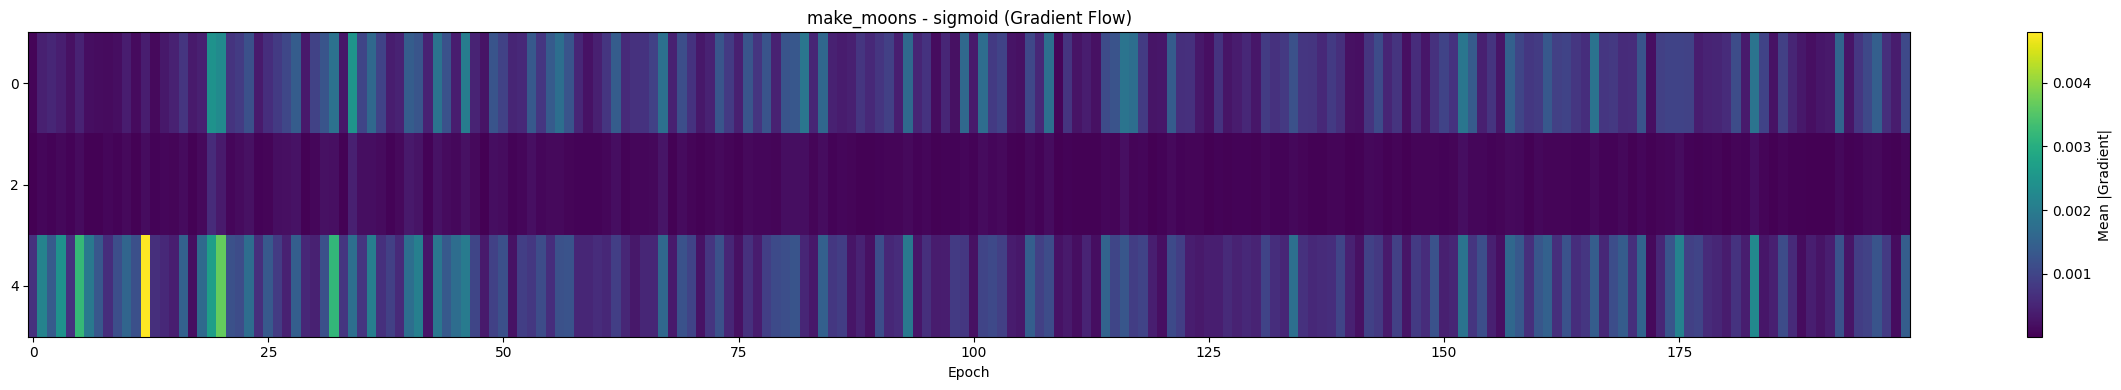

In [29]:
"""Exp B visualization — activation distribution at early / mid / late."""

epoch_labels_b = {1: "early", 100: "mid", 200: "late"}

for activation, model in exp_b_models.items():
    out_dir = os.path.join(OUTPUT_BASE, "experiment_b", "make_moons", activation)

    # early / mid / late 시점별 activation 분포 히스토그램
    for ep, acts in exp_b_act_snapshots[activation].items():
        label = epoch_labels_b.get(ep, f"ep{ep}")
        plot_activation_distributions(
            acts,
            plot_type="histogram",
            title_prefix=f"{activation} {label}(epoch{ep})",
            save_path=os.path.join(out_dir, f"activation_hist_{label}.png"),
        )

    # Dead ReLU 비율 히트맵
    plot_dead_relu_heatmap(
        model=model,
        loader=moons_train,
        device=DEVICE,
        max_batches=10,
        save_path=os.path.join(out_dir, "dead_relu_heatmap.png"),
    )

    dead_ratio = compute_dead_relu_ratio(
        model=model,
        loader=moons_train,
        device=DEVICE,
        max_batches=10,
    )
    print(f"[{activation}] dead ratio:", dead_ratio)

    # Gradient 흐름 히트맵
    plot_gradient_flow_heatmap(
        exp_b_grads[activation],
        title=f"make_moons - {activation} (Gradient Flow)",
        save_path=os.path.join(out_dir, "grad_flow_heatmap.png"),
    )

## 8. 실험 C: SGD vs SGD+Momentum vs Adam

동일한 데이터/모델 조건에서 옵티마이저를 비교합니다.

Epoch   1/20 | Train Loss 0.5747 Acc 0.7887 | Test Loss 0.4429 Acc 0.8386
Epoch  10/20 | Train Loss 0.2406 Acc 0.9098 | Test Loss 0.3419 Acc 0.8833
Epoch  20/20 | Train Loss 0.1655 Acc 0.9374 | Test Loss 0.3601 Acc 0.8861


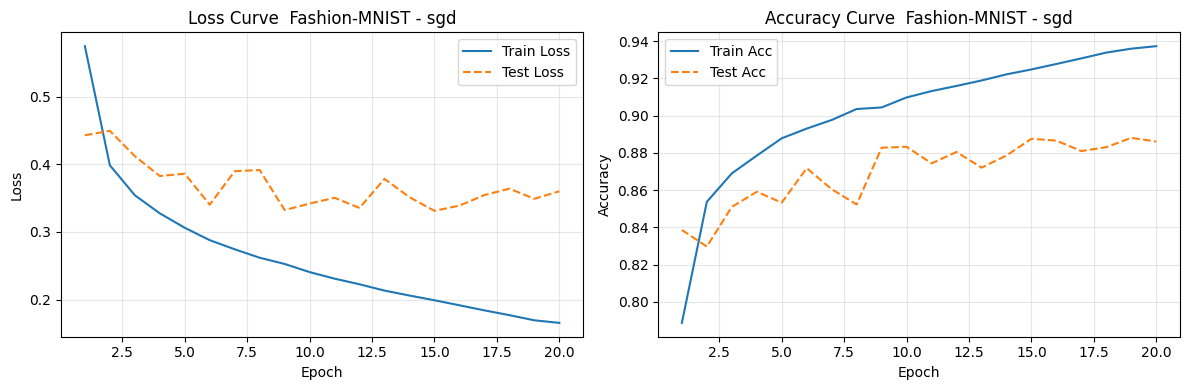

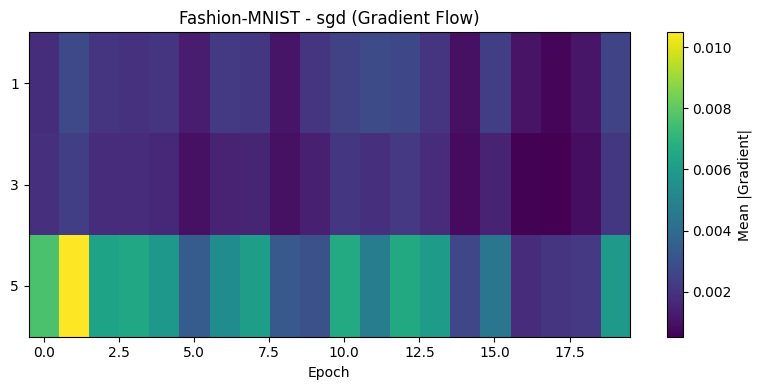

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:1

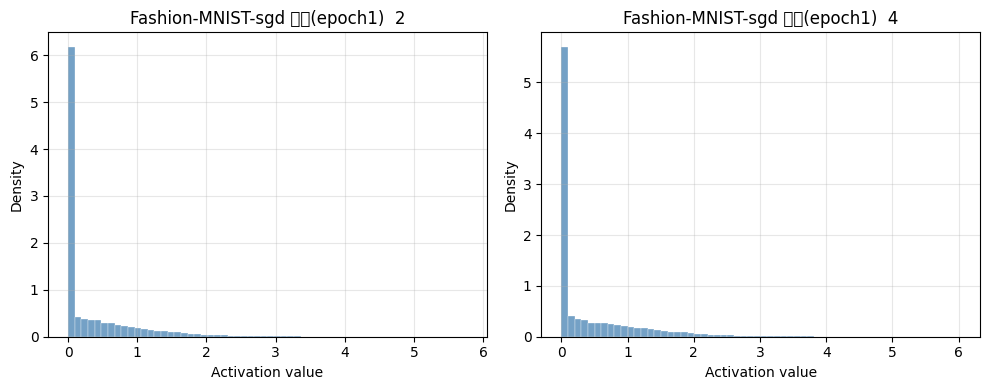

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


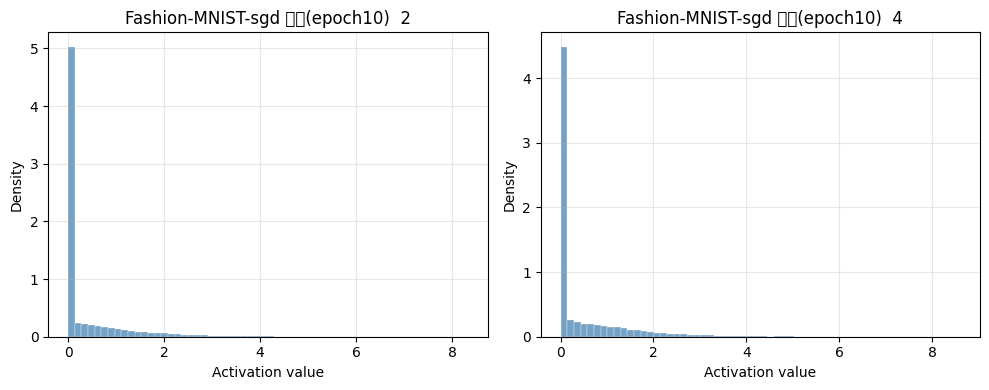

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


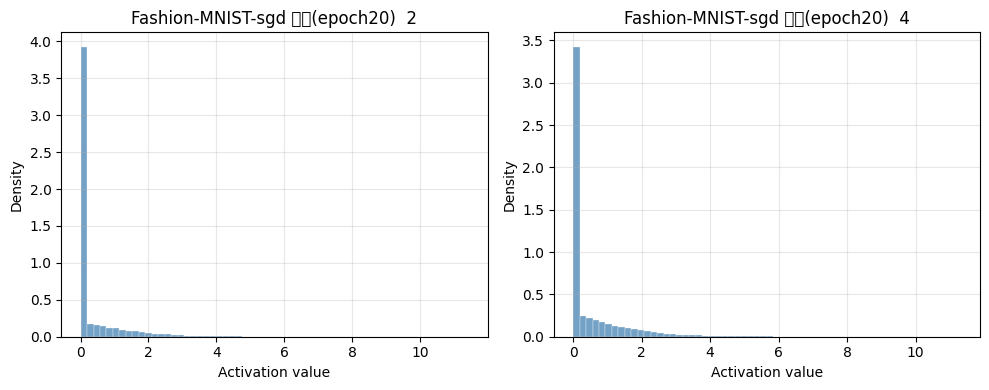

Epoch   1/20 | Train Loss 0.5674 Acc 0.7959 | Test Loss 0.4444 Acc 0.8396
Epoch  10/20 | Train Loss 0.2400 Acc 0.9103 | Test Loss 0.3425 Acc 0.8847
Epoch  20/20 | Train Loss 0.1641 Acc 0.9378 | Test Loss 0.3526 Acc 0.8839


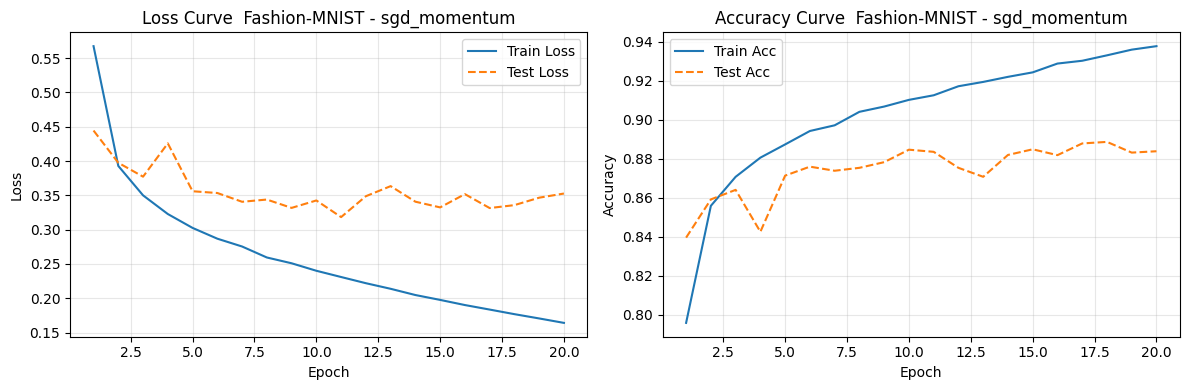

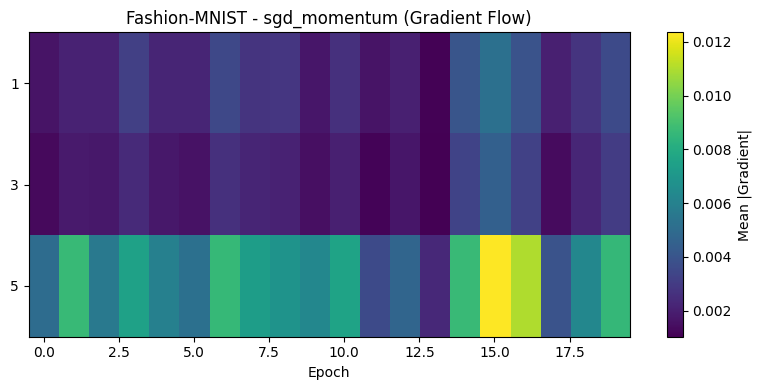

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:1

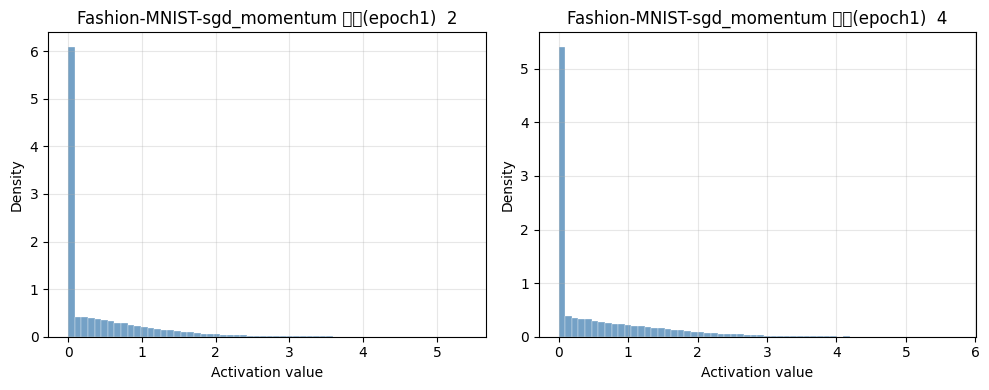

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


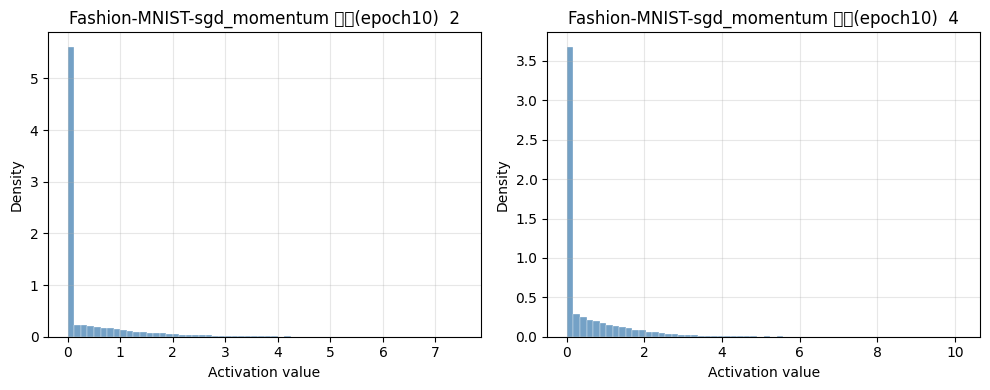

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


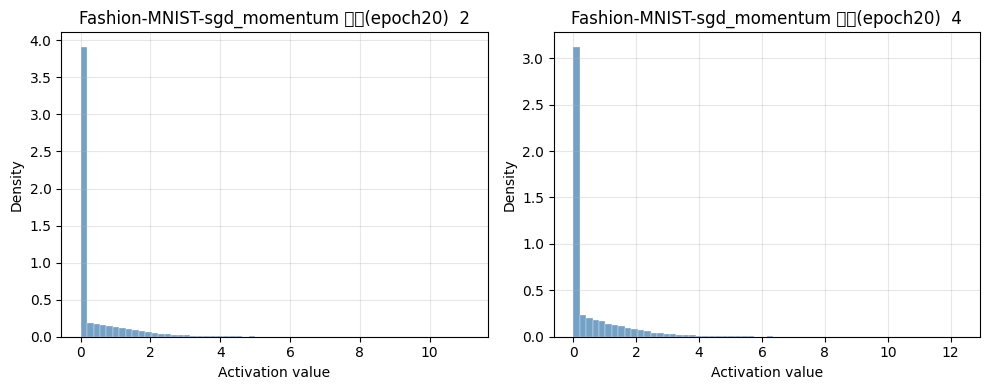

Epoch   1/20 | Train Loss 0.4976 Acc 0.8186 | Test Loss 0.4354 Acc 0.8440
Epoch  10/20 | Train Loss 0.2209 Acc 0.9165 | Test Loss 0.3495 Acc 0.8795
Epoch  20/20 | Train Loss 0.1429 Acc 0.9464 | Test Loss 0.3874 Acc 0.8935


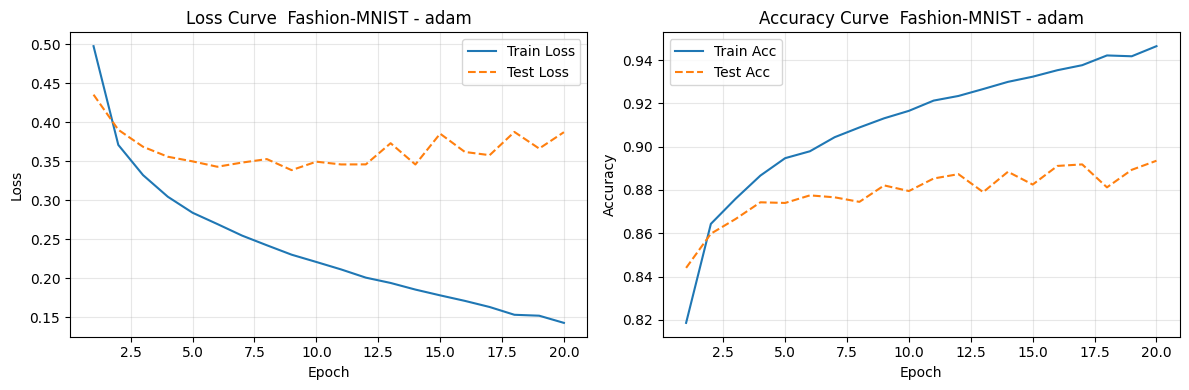

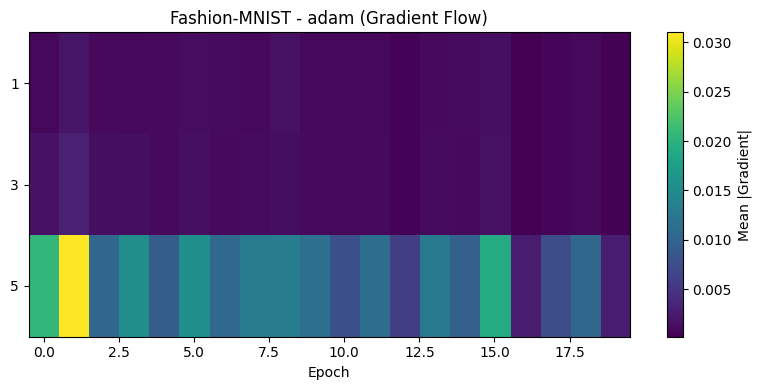

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:1

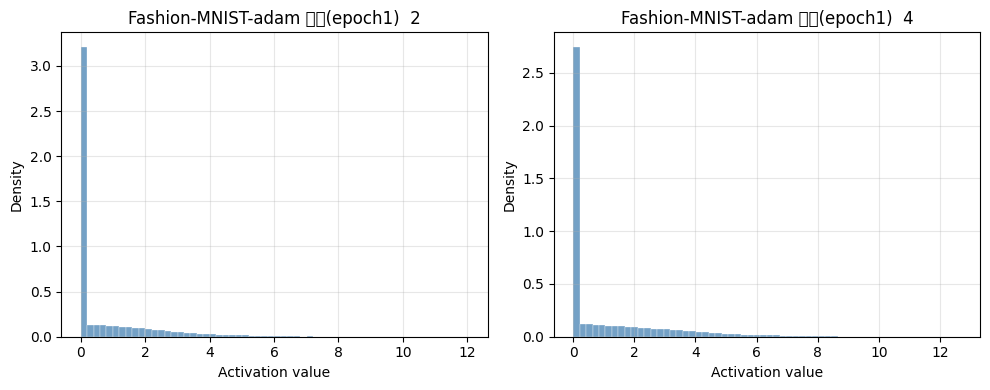

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


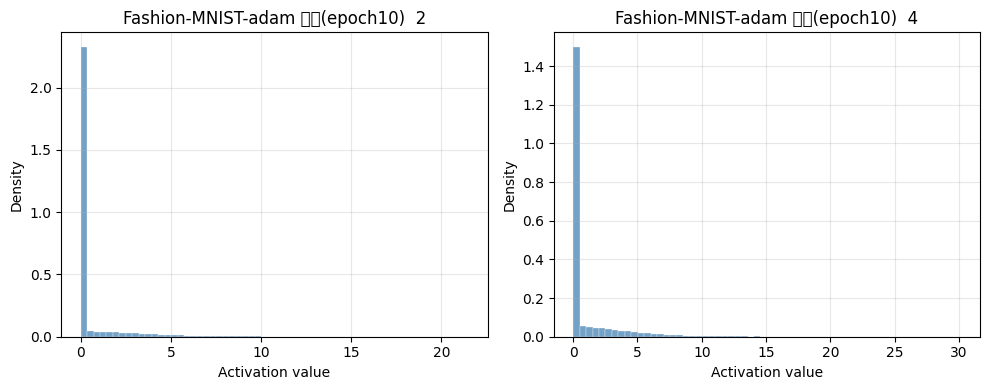

/home/leelab/projects/vision/mlp/utils.py:428: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leelab/projects/vision/mlp/utils.py:430: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/home/leelab/projects/vision/mlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


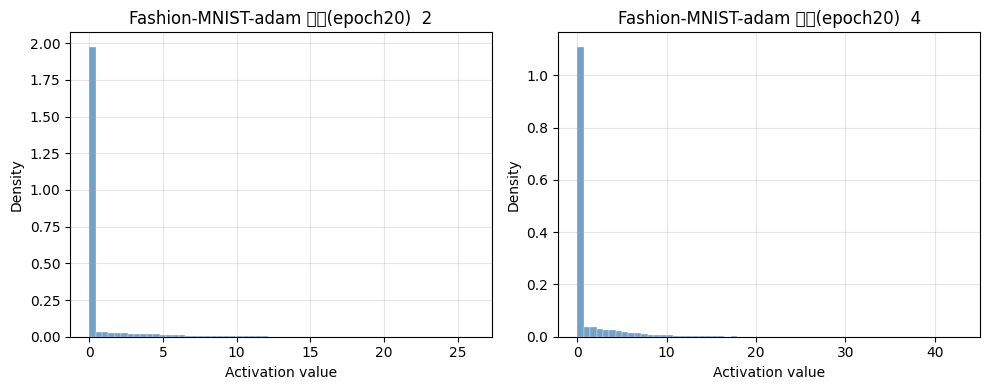

,optimizer,lr,final_acc,min_loss,conv_epoch
0,sgd,0.100,88.61,0.331226,15
1,sgd_momentum,0.010,88.39,0.318283,11
2,adam,0.001,89.35,0.338700,9


In [30]:
"""실험 C 기본 비교."""

EXP_C_EPOCHS = 20
EXP_C_SNAPSHOTS = [1, 10, 20]  # early / mid / late

exp_c_results = []

optimizer_specs = [
    ("sgd", 0.1, dict(momentum=0.0)),
    ("sgd_momentum", 0.01, dict(momentum=0.9)),
    ("adam", 0.001, dict()),
]

for opt_name, lr, extra in optimizer_specs:
    model = build_mlp(
        input_size=28 * 28,
        num_classes=fashion_classes,
        activation="relu",
        with_flatten=True,
    ).to(DEVICE)

    loss_fn = nn.CrossEntropyLoss()

    if opt_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, **extra)

    grad_history: dict = {}
    activation_snapshots: dict = {}

    train_losses, train_accs, test_losses, test_accs = train_model(
        model=model,
        train_loader=fashion_train,
        test_loader=fashion_test,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=DEVICE,
        epochs=EXP_C_EPOCHS,
        use_softmax_output=False,
        grad_history=grad_history,
        snapshot_epochs=EXP_C_SNAPSHOTS,
        activation_snapshots=activation_snapshots,
    )

    out_dir = os.path.join(OUTPUT_BASE, "experiment_c", "baseline", opt_name)
    os.makedirs(out_dir, exist_ok=True)

    plot_loss_acc(
        train_losses,
        train_accs,
        test_losses,
        test_accs,
        title=f"Fashion-MNIST - {opt_name}",
        save_path=os.path.join(out_dir, "loss_acc.png"),
    )

    plot_gradient_flow_heatmap(
        grad_history,
        title=f"Fashion-MNIST - {opt_name} (Gradient Flow)",
        save_path=os.path.join(out_dir, "grad_flow_heatmap.png"),
    )

    # Activation distribution visualization (early / mid / late)
    epoch_labels_c = {1: "early", 10: "mid", 20: "late"}
    for ep, acts in activation_snapshots.items():
        label = epoch_labels_c.get(ep, f"ep{ep}")
        plot_activation_distributions(
            acts,
            plot_type="histogram",
            title_prefix=f"Fashion-MNIST-{opt_name} {label}(epoch{ep})",
            save_path=os.path.join(out_dir, f"activation_hist_{label}.png"),
        )

    exp_c_results.append({
        "optimizer": opt_name,
        "lr": lr,
        "final_acc": test_accs[-1] * 100.0,
        "min_loss": min(test_losses),
        "conv_epoch": convergence_epoch(test_losses),
    })

exp_c_df = pd.DataFrame(exp_c_results)
exp_c_df

## 9. 실험 C: 학습률별 비교 및 ExponentialLR 비교

학습률 0.1, 0.01, 0.001에 대해 옵티마이저별 성능을 표로 정리하고, ExponentialLR 적용 여부를 비교합니다.

In [26]:
"""학습률 그리드 및 ExponentialLR 비교."""

EXP_C_GRID_EPOCHS = 20

lr_grid = [0.1, 0.01, 0.001]
optimizer_names = ["sgd", "sgd_momentum", "adam"]

exp_c_grid_results = []

for opt_name in optimizer_names:
    for lr in lr_grid:
        model = build_mlp(
            input_size=28 * 28,
            num_classes=fashion_classes,
            activation="relu",
            with_flatten=True,
        ).to(DEVICE)

        loss_fn = nn.CrossEntropyLoss()
        if opt_name == "adam":
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        elif opt_name == "sgd_momentum":
            optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
        else:
            optimizer = torch.optim.SGD(model.parameters(), lr=lr)

        train_losses, train_accs, test_losses, test_accs = train_model(
            model=model,
            train_loader=fashion_train,
            test_loader=fashion_test,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=DEVICE,
            epochs=EXP_C_GRID_EPOCHS,
            use_softmax_output=False,
        )

        exp_c_grid_results.append({
            "optimizer": opt_name,
            "lr": lr,
            "final_acc": test_accs[-1] * 100.0,
            "min_loss": min(test_losses),
            "conv_epoch": convergence_epoch(test_losses),
        })

exp_c_grid_df = pd.DataFrame(exp_c_grid_results)
exp_c_grid_df

# ExponentialLR 비교 (예: SGD, lr=0.1)
exp_c_decay_results = []

for use_decay in [False, True]:
    model = build_mlp(
        input_size=28 * 28,
        num_classes=fashion_classes,
        activation="relu",
        with_flatten=True,
    ).to(DEVICE)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
    scheduler = None
    if use_decay:
        scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

    train_losses, train_accs, test_losses, test_accs = train_model(
        model=model,
        train_loader=fashion_train,
        test_loader=fashion_test,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=DEVICE,
        epochs=EXP_C_GRID_EPOCHS,
        use_softmax_output=False,
        scheduler=scheduler,
    )

    tag = "exp_lr" if use_decay else "no_decay"
    exp_c_decay_results.append({
        "setting": tag,
        "final_acc": test_accs[-1] * 100.0,
        "min_loss": min(test_losses),
        "conv_epoch": convergence_epoch(test_losses),
    })

exp_c_decay_df = pd.DataFrame(exp_c_decay_results)
exp_c_decay_df

Epoch   1/20 | Train Loss 0.5734 Acc 0.7900 | Test Loss 0.4497 Acc 0.8371
Epoch  10/20 | Train Loss 0.2419 Acc 0.9096 | Test Loss 0.4824 Acc 0.8367
Epoch  20/20 | Train Loss 0.1652 Acc 0.9374 | Test Loss 0.3809 Acc 0.8795
Epoch   1/20 | Train Loss 0.9555 Acc 0.7066 | Test Loss 0.6170 Acc 0.7762
Epoch  10/20 | Train Loss 0.3603 Acc 0.8719 | Test Loss 0.3948 Acc 0.8583
Epoch  20/20 | Train Loss 0.2930 Acc 0.8950 | Test Loss 0.3638 Acc 0.8715
Epoch   1/20 | Train Loss 2.0789 Acc 0.3539 | Test Loss 1.7899 Acc 0.5708
Epoch  10/20 | Train Loss 0.6028 Acc 0.7817 | Test Loss 0.6155 Acc 0.7728
Epoch  20/20 | Train Loss 0.4959 Acc 0.8247 | Test Loss 0.5198 Acc 0.8121
Epoch   1/20 | Train Loss 0.6713 Acc 0.7655 | Test Loss 0.6111 Acc 0.7981
Epoch  10/20 | Train Loss 0.4959 Acc 0.8403 | Test Loss 0.5617 Acc 0.8389
Epoch  20/20 | Train Loss 0.4727 Acc 0.8478 | Test Loss 0.5415 Acc 0.8182
Epoch   1/20 | Train Loss 0.5691 Acc 0.7960 | Test Loss 0.4369 Acc 0.8440
Epoch  10/20 | Train Loss 0.2374 Acc 0

,setting,final_acc,min_loss,conv_epoch
0,no_decay,88.79,0.334457,16
1,exp_lr,88.93,0.312577,16


## 10. 결과 정리 (pandas DataFrame)

각 실험의 핵심 지표를 DataFrame으로 정리합니다.

In [27]:
"""최종 결과 표 출력."""

# 실험 A 결과
exp_a_df_sorted = exp_a_df.sort_values(["dataset", "loss"]).reset_index(drop=True)

# 실험 B 결과
exp_b_df_sorted = exp_b_df.sort_values(["activation"]).reset_index(drop=True)

# 실험 C 결과
exp_c_df_sorted = exp_c_df.sort_values(["optimizer"]).reset_index(drop=True)

print("[실험 A 결과]\n", exp_a_df_sorted)
print("\n[실험 B 결과]\n", exp_b_df_sorted)
print("\n[실험 C 기본 비교 결과]\n", exp_c_df_sorted)
print("\n[실험 C 학습률 그리드]\n", exp_c_grid_df)
print("\n[실험 C ExponentialLR 비교]\n", exp_c_decay_df)

[실험 A 결과]
          dataset           loss  final_acc  min_loss  conv_epoch
0         Digits  cross_entropy  97.777778  0.062978          29
1         Digits    mse_softmax  98.055556  0.003104          29
2  Fashion-MNIST  cross_entropy  89.120000  0.334227          14
3  Fashion-MNIST    mse_softmax  88.470000  0.016658          12

[실험 B 결과]
   activation  dead_relu_ratio(%)  final_acc(%)  min_loss  conv_epoch
0  leakyrelu               12.89         95.00  0.088645          26
1       relu               42.58         96.25  0.093952          34
2    sigmoid                0.00         96.00  0.091472         176

[실험 C 기본 비교 결과]
       optimizer     lr  final_acc  min_loss  conv_epoch
0          adam  0.001      88.81  0.330895           9
1           sgd  0.100      89.25  0.328897          14
2  sgd_momentum  0.010      88.27  0.325473          13

[실험 C 학습률 그리드]
       optimizer     lr  final_acc  min_loss  conv_epoch
0           sgd  0.100      87.95  0.350860          15
1    